# AI MiniLab - Logistic Regression and SVM
**Course:** DS 7331 – Artificial Intelligence I 
**Team Members:** Johnny Vogt, Drew Nunnally, Devin Streeter, Mike Flores  
**Date:** 2/8/2026

---

## Business Understanding

Phishing attacks are a significant cybersecurity threat in which malicious websites attempt to deceive users into revealing sensitive information such as login credentials, financial data, or personal information. These attacks have proven effective at bypassing human intuition, even among vigilant users, and often result in financial loss or reputational damage. As phishing techniques continue to evolve, automated detection methods are increasingly necessary to protect users and organizations.

The dataset used in this project consists of URLs accompanied by a variety of attributes describing both the structure of the URL and characteristics of the associated website. Each URL is assigned a binary label indicating whether it is classified as a **phishing** or **legitimate** website (1 = legitimate, 0 = phishing). The dataset was collected to support the study and detection of phishing websites and to enable the development of predictive models that can identify malicious links before users interact with them.

The primary objective of this analysis is to understand how individual features relate to the phishing classification and to determine which attributes are most informative for distinguishing between legitimate and phishing websites. If meaningful differences exist between the patterns of phishing and legitimate URLs, then the dataset provides useful information for building effective prediction models. Preliminary feature correlations, such as indicators related to copyright information, social network presence, and special character usage in URLs, suggest that certain attributes may be associated with specific classifications.

A successful prediction model in this context prioritizes the accurate detection of phishing websites while minimizing misclassification of legitimate sites. From a practical standpoint, false negatives—failing to identify phishing links—pose a greater risk than false positives, as undetected phishing attacks can lead to significant security breaches and financial harm. Therefore, this exploratory analysis focuses on understanding the structure, distributions, and relationships within the data to support effective phishing detection in subsequent modeling efforts.

**Source:**  
Prasad, A., & Chandra, S. (2023). *PhiUSIIL: A diverse security profile empowered phishing URL detection framework based on similarity index and incremental learning*. Computers & Security, 103545. https://doi.org/10.1016/j.cose.2023.103545


## Load Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display utilities
from IPython.display import display

from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
# Import dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

## Display dataset dimensions (rows, columns)

In [3]:
rows, cols = df.shape
print(f"The dataset contains {rows:,} rows and {cols} columns.")

The dataset contains 235,795 rows and 56 columns.


## Check for missing data
EDA showed that there was no missing data

## Check for duplicate data

In [4]:
# Check for duplicate rows
print("Duplicate Rows")
# Counts ONLY exact row level duplicates
display(df.duplicated().sum())

print("Duplicate URLs (only)")
# Many URLs appear more than once, but with small differences in feature values
# (e.g., URLLength differs by 1 due to data collection timing or parsing)
# These are NOT full row duplicates, only URL-level duplicates
# Count duplicate values based only on the URL column
# It is safe to just drop all duplicates
display(df.duplicated(subset=["URL"]).sum())

Duplicate Rows


0

Duplicate URLs (only)


425

Duplicates Summary

A total of **425 duplicate URLs** were identified in the dataset. These duplicates correspond to repeated occurrences of the same URL while exhibiting minor variations in certain feature values. As a result, these records are not exact row-level duplicates but represent multiple observations associated with the same URL.

To avoid potential bias and redundancy in downstream analysis, duplicate URLs were removed by retaining only the first occurrence of each URL. The number of removed records represents approximately **0.18%** of the dataset, and therefore this preprocessing step is not expected to materially affect the overall analysis or modeling results.


Deal with the duplicate URLs by dropping the duplicate and keeping the first occurence.

In [15]:
# Drop the duplicate URLs code
# Identify duplicate URLs
dup_url_mask = df.duplicated(subset=["URL"], keep=False)

# Remove duplicate URLs (keep the first occurrence)
df_dedup = df.drop_duplicates(subset=["URL"], keep="first")

In [16]:
rows, cols = df_dedup.shape
print(f"After dropping the duplicate URLs, the dataset contains {rows:,} rows and {cols} columns.")

After dropping the duplicate URLs, the dataset contains 235,370 rows and 56 columns.


Remove Features

Removing Filename, URL, Domain, Title, TLD, and URL SImilarityindex
Some for overfitting and some for making everything a numerical value

In [6]:
df_dedup = df_dedup.drop(columns=["FILENAME", "URL", "Domain", "Title", "TLD", "URLSimilarityIndex"], axis =1)


Test/Train Split

In [7]:
if 'label' in df_dedup:
    y = df_dedup['label'].values # Label is what we are trying to predict
    X = df_dedup.drop('label', axis=1).values # Everything but label

#Setting up the Cross Validation using ShuffleSplit 
num_cv_iterations = 3
num_instances = len(y)
cv_object = ShuffleSplit(n_splits=num_cv_iterations, test_size=0.2)
                         
print(cv_object)
print("X shape:", X.shape)
print("y shape:", y.shape)

ShuffleSplit(n_splits=3, random_state=None, test_size=0.2, train_size=None)
X shape: (235370, 49)
y shape: (235370,)


Logistic Regression

In [8]:
# Setting up the Logistic Regression Object
lr_clf = LogisticRegression(C=1.0, class_weight=None, solver='liblinear' ) # get object

iter_num=0

# Looping the CV Object created earlier to create new train/test splits while using them to train and test on our reusable logistic regression model. 
# Since we are not using a seed, the output will be different each time its ran. 
for train_indices, test_indices in cv_object.split(X,y): 
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]
    
    # Training the model and putting predictions into y_hat
    lr_clf.fit(X_train,y_train)
    y_hat = lr_clf.predict(X_test)

    # Displaying the accuracy and Confusion matrix for each iteration (3)
    acc = mt.accuracy_score(y_test,y_hat)
    conf = mt.confusion_matrix(y_test,y_hat)
    print("====Iteration",iter_num," ====")
    print("accuracy", acc )
    print("confusion matrix\n",conf)
    iter_num+=1
    

====Iteration 0  ====
accuracy 0.9950503462633301
confusion matrix
 [[20182   106]
 [  127 26659]]
====Iteration 1  ====
accuracy 0.9952627777541743
confusion matrix
 [[20176    93]
 [  130 26675]]
====Iteration 2  ====
accuracy 0.9959213153757913
confusion matrix
 [[20053    88]
 [  104 26829]]


Logit Weights

In [9]:
# Creating Weights for each feature
weights = lr_clf.coef_.T # Transposing the coefficients
variable_names = df_dedup.columns
for coef, name in zip(weights,variable_names): #Looping through the weights and variable names together
    print(name, 'has weight of', coef[0])
    

URLLength has weight of -0.2576290150785754
DomainLength has weight of 0.05069365037259829
IsDomainIP has weight of -0.0002765986137508447
CharContinuationRate has weight of -0.007237737828412232
TLDLegitimateProb has weight of 0.0029972609945436886
URLCharProb has weight of 6.130424632840598e-05
TLDLength has weight of -0.04108641113352642
NoOfSubDomain has weight of 0.011473764116581723
HasObfuscation has weight of -0.00027485739339499083
NoOfObfuscatedChar has weight of -0.001205876741533946
ObfuscationRatio has weight of -1.7475479197080164e-05
NoOfLettersInURL has weight of -0.10302657169098242
LetterRatioInURL has weight of -0.0035713158515167497
NoOfDegitsInURL has weight of -0.13848361441895407
DegitRatioInURL has weight of -0.004061483533098365
NoOfEqualsInURL has weight of -0.0015408161942906283
NoOfQMarkInURL has weight of -0.001533107518016536
NoOfAmpersandInURL has weight of -0.0004200180645068464
NoOfOtherSpecialCharsInURL has weight of -0.09051785986963529
SpacialCharRat

Setting Scales and Plotting Weights

accuracy: 0.9990015719930323
[[20104    37]
 [   10 26923]]
LetterRatioInURL has weight of -2.4524267363662053
DegitRatioInURL has weight of -1.9847848069936422
SpacialCharRatioInURL has weight of -1.953416572209849
NoOfOtherSpecialCharsInURL has weight of -1.1535305291979325
LargestLineLength has weight of -1.1338558783908406
NoOfLettersInURL has weight of -1.0265381673528848
NoOfDegitsInURL has weight of -0.5608748479990722
URLLength has weight of -0.4284812270523067
CharContinuationRate has weight of -0.31494727446127824
NoOfQMarkInURL has weight of -0.2797345974557962
TLDLength has weight of -0.22719307094227614
NoOfURLRedirect has weight of -0.20596042020944083
HasPasswordField has weight of -0.20082114107751006
TLDLegitimateProb has weight of -0.1786759535033704
HasObfuscation has weight of -0.1625725364845714
Crypto has weight of -0.11224443772977133
ObfuscationRatio has weight of -0.103663064974258
URLTitleMatchScore has weight of -0.09235933357863535
NoOfEqualsInURL has weight

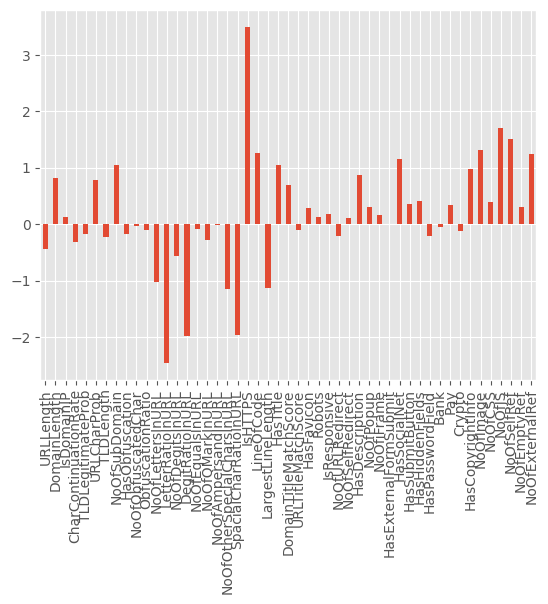

In [10]:
# scale attributes by the training set
scl_obj = StandardScaler()
scl_obj.fit(X_train) # Finding the scale of X_train

X_train_scaled = scl_obj.transform(X_train) # apply to training
X_test_scaled = scl_obj.transform(X_test) # apply to test

# train the model 
lr_clf = LogisticRegression(C=0.05, solver='liblinear')
lr_clf.fit(X_train_scaled,y_train)  # train object with scaled data

y_hat = lr_clf.predict(X_test_scaled) # get predictions on scaled data

acc = mt.accuracy_score(y_test,y_hat)
conf = mt.confusion_matrix(y_test,y_hat)
print('accuracy:', acc )
print(conf )

# sorting attributes based on their weights
zip_vars = zip(lr_clf.coef_.T,df_dedup.columns) # combine attributes
zip_vars = sorted(zip_vars)
for coef, name in zip_vars:
    print(name, 'has weight of', coef[0]) # now print them out


# Plotting the weights
%matplotlib inline
plt.style.use('ggplot')

# Get column names excluding 'label'
feature_names = df_dedup.drop('label', axis=1).columns

weights = pd.Series(lr_clf.coef_[0], index=feature_names)
weights.plot(kind='bar')
plt.show()

SVM - Test/Train Split

In [11]:
# Recreating the train/test and scaling for SVM
for train_indices, test_indices in cv_object.split(X,y): 
    X_train = X[train_indices]
    y_train = y[train_indices]
    
    X_test = X[test_indices]
    y_test = y[test_indices]
    
X_train_scaled = scl_obj.transform(X_train) # apply to training
X_test_scaled = scl_obj.transform(X_test) # apply to test

SVM - Fit Model

In [12]:
# train the svm model similar to the logit model via object creating and training
svm_clf = SVC(C=0.5, kernel='linear', degree=3, gamma='auto') # get object
svm_clf.fit(X_train_scaled, y_train)  # train object with scaled data

y_hat = svm_clf.predict(X_test_scaled) # get predictions on scaled data

#Print accuracy and confusion matrix for SVM
acc = mt.accuracy_score(y_test,y_hat)
conf = mt.confusion_matrix(y_test,y_hat)
print('accuracy:', acc )
print(conf)

accuracy: 0.9995538938692272
[[20088    17]
 [    4 26965]]


SVM - Metric and Weights

(433, 49)
(433,)
[215 218]
[[-1.10316481e+00  1.87144646e+00  1.05471187e-15 -1.24143024e-01
  -5.15894214e-02  3.42157775e-01 -8.55388804e-02  3.03719820e-01
  -2.77555756e-16 -2.60208521e-17  1.66533454e-16 -4.00545645e+00
  -1.26517451e+00 -1.38211881e+00 -1.13269230e+00 -8.46545056e-16
   1.77635684e-15  5.34294831e-16 -8.89337263e-01 -7.26697477e-01
   2.39878675e+00  2.83184988e+00 -4.57509355e+00  5.41794555e-01
   7.56491954e-01 -5.78130790e-01  9.90990789e-02 -2.60956216e-02
   6.93865888e-02 -1.06562327e-01  1.61218849e-01  4.19574090e-01
   8.97276172e-01  3.91095713e-01 -7.16248014e-02  6.05800640e-01
   1.65675895e-01  1.33746459e-01 -8.31648221e-02 -1.48201979e-02
   1.75301323e-01 -3.71787627e-02  4.70571321e-01  3.24329448e+00
   1.67517322e+00  1.24376414e+00  3.68737176e+00  3.87292873e-01
   2.83709756e+00]]


<Axes: >

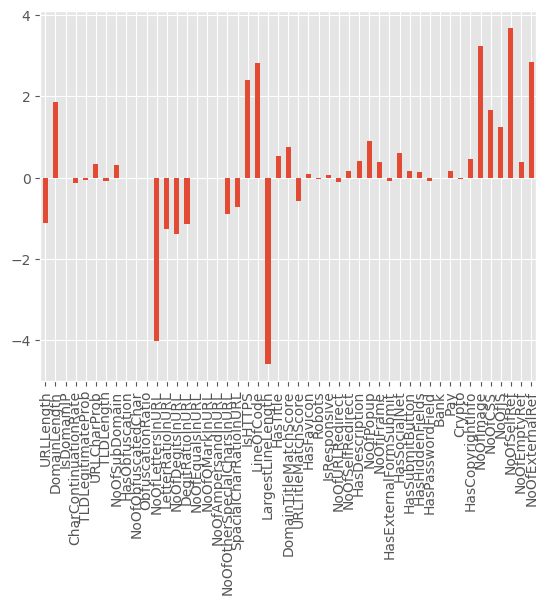

In [13]:
# Print support vectors
print(svm_clf.support_vectors_.shape)
print(svm_clf.support_.shape)
print(svm_clf.n_support_ )

# Printing out coefficients for SVM
print(svm_clf.coef_)
weights = pd.Series(svm_clf.coef_[0],index=feature_names)
weights.plot(kind='bar')

## Introduction

This miniproject focuses on applying supervised classification techniques to the problem of phishing URL detection. Using a large, structured dataset containing approximately 235,000 URLs represented by 49 numerical features, two widely used classification models, logistic regression and a linear support vector machine (SVM), were developed and evaluated. The dataset was split into 80% training data and 20% testing data, and model performance was assessed using confusion matrices and overall classification accuracy. In addition to comparing predictive performance, this project examines model efficiency, interpretability, feature importance, and the role of support vectors in understanding classification behavior.

## Model Performance Using an 80/20 Train–Test Split (Logistic vs SVM)

To evaluate model performance, the dataset was randomly split into 80% training data and 20% testing data. Both a logistic regression model and a linear support vector machine (SVM) were trained on the same training data and evaluated on the same test set. Model performance was assessed using confusion matrices and overall classification accuracy.

**Logistic Regression Results**

The logistic regression model achieved very high classification performance on the test set.

**Confusion Matrix (Logistic Regression) Interpretation:**

20,104 phishing URLs were correctly identified as phishing

37 phishing URLs were incorrectly classified as legitimate

26,923 legitimate URLs were correctly classified as legitimate

10 legitimate URLs were incorrectly flagged as phishing

This model performs extremely well, with only a very small number of misclassifications. Most errors fall into two minor categories: a small number of phishing URLs that were not detected and a small number of legitimate websites that were incorrectly flagged. Overall, the model demonstrates strong reliability for the classification task.


**Support Vector Machine (SVM) Results**

The linear SVM model produced slightly better performance than logistic regression on the same test data.

**Confusion Matrix (SVM) Interpretation:**

20,088 phishing URLs were correctly identified as phishing

17 phishing URLs were incorrectly classified as legitimate

26,965 legitimate URLs were correctly classified as legitimate

4 legitimate URLs were incorrectly flagged as phishing

The SVM model makes even fewer errors than logistic regression. It reduces both types of misclassification: fewer phishing URLs are missed, and fewer legitimate websites are incorrectly flagged. This results in slightly higher overall accuracy.

**Summary Comparison**

Both models achieve exceptionally high performance, with accuracy above 99.9%. The SVM model performs marginally better by reducing the number of incorrect classifications in both categories. However, the difference is small, and both models are highly effective for this classification task.

## Parameter Tuning Summary

Parameter tuning was performed for both models to assess the impact of regularization strength and feature scaling on classification performance and model stability. For logistic regression, the model was initially trained using the default regularization value of C = 1.0. After applying feature scaling using standardization, the regularization parameter was reduced to C = 0.05. This stronger regularization reduced coefficient variability, improved generalization, and increased test accuracy from approximately 99.5% to 99.9%, while also producing more stable and interpretable feature weights.

For the support vector machine, a linear kernel was used with a regularization parameter of C = 0.5 and gamma = "auto". This moderate value of C allowed the model to maintain a wide separating margin while still fitting the training data effectively. The resulting model achieved test accuracy above 99.9%, indicating strong class separation without overfitting.

Overall, both models achieved extremely high classification performance, with test accuracy exceeding 99.9%. Additional parameter tuning beyond these values resulted in negligible performance improvements, demonstrating that the dataset is highly separable and that the selected parameter settings provide an effective balance between accuracy, generalization, and model stability.

## Model Comparison: Accuracy, Efficiency, and Interpretability

**Prediction Accuracy**

Both models achieved extremely high classification accuracy on the 80/20 train–test split, exceeding 99.9% overall. However, the linear support vector machine (SVM) demonstrated a slight advantage in predictive performance. The SVM produced fewer misclassifications in both categories, reducing the number of false negatives (missed phishing URLs) and false positives (legitimate URLs incorrectly flagged). Specifically, the SVM reduced phishing misclassifications from 37 to 17 and reduced legitimate-site misclassifications from 10 to 4 when compared to logistic regression.

Logistic regression performed nearly as well, with accuracy also close to 99.9%, but it produced a slightly higher total error count. While the difference in performance is small, the SVM’s improvement is meaningful in a security context where minimizing missed phishing attempts is particularly important.

Overall, in terms of pure prediction accuracy, the linear SVM is marginally superior, although both models perform exceptionally well due to the high separability of the dataset.

**Training Time and Computational Efficiency**

The dataset used for this task contains approximately 235,000 observations and 49 numerical features after preprocessing. Logistic regression, trained using the liblinear solver, is generally faster and more computationally efficient for large tabular datasets. Its optimization problem is simpler, converges quickly, and scales well as the number of training examples increases.

The SVM, implemented using a linear kernel, typically requires more computational effort during training because it solves a margin-based optimization problem. As dataset size increases, this optimization can become more expensive compared to logistic regression. However, once the SVM is trained, predictions depend only on a relatively small subset of training points known as support vectors, which allows inference to remain efficient.

In this case, both models trained in reasonable time, but logistic regression is more scalable and computationally efficient for large-scale applications, while the SVM accepts slightly higher training cost in exchange for improved accuracy.

**Interpretability**

Logistic regression offers a clear advantage in interpretability. Its learned coefficients directly indicate how each feature influences the likelihood of a URL being classified as legitimate or phishing. Holding all other variables constant, positive coefficients increase the probability of a legitimate classification, while negative coefficients increase the likelihood of phishing. This makes logistic regression particularly useful for explaining model decisions and understanding feature importance.

Although the SVM used in this analysis is also linear and has an associated weight vector, its interpretation is more geometric in nature. The model focuses on maximizing the margin between classes, and its key insights come from the support vectors rather than probability estimates. As a result, SVM coefficients are less intuitive for explaining individual feature contributions in practical settings.

**Overall Assessment**

- Accuracy: SVM (slightly higher, fewer errors)
- Training efficiency and scalability: Logistic regression
- Interpretability: Logistic regression

Given that this task involves phishing detection, where false negatives can carry significant risk, the SVM’s slightly higher accuracy and reduced number of missed phishing URLs make it an attractive choice for deployment. However, logistic regression remains highly valuable for model transparency and explanation, making it well suited for analytical interpretation and reporting purposes.

## Interpreting Logistic Regression Weights (Feature Importance)

Logistic regression coefficients were analyzed after scaling the input features using StandardScaler and retraining the model with a regularization parameter of C = 0.05. In this model, the target variable is encoded as follows:

- Label = 1: Legitimate URL
- Label = 0: Phishing URL

As a result, the sign of each coefficient has a direct interpretation:

- Positive coefficients increase the likelihood that a URL is classified as legitimate.
- Negative coefficients increase the likelihood that a URL is classified as phishing.

**Features Strongly Associated with Phishing (Negative Weights)**

The following features exhibit large negative coefficients, indicating a strong association with phishing URLs:
- LetterRatioInURL
- DegitRatioInURL
- SpacialCharRatioInURL
- NoOfOtherSpecialCharsInURL
- NoOfLettersInURL
- NoOfDegitsInURL
- URLLength
- NoOfURLRedirect
- HasPasswordField
- URLTitleMatchScore

These features describe URL structure and complexity. Long URLs with high character counts, digit ratios, special characters, and frequent redirects are indicative of masking, a common tactic in phishing attacks. The presence of password fields and low URL–title similarity further suggest phishing intent, as attackers often mimic login pages using deceptive or mismatched URLs.

**Features Strongly Associated with Legitimate Websites (Positive Weights)**

The following features have large positive coefficients, indicating a strong association with legitimate websites:
- IsHTTPS
- NoOfJS
- NoOfImage
- NoOfSelfRef
- NoOfExternalRef
- HasTitle
- HasDescription
- HasCopyrightInfo
- HasSocialNet
- LineOfCode
- DomainTitleMatchScore
- NoOfCSS

These features reflect page quality and completeness. Legitimate websites are more likely to use HTTPS, include descriptive metadata, link to social media, and contain richer frontend content such as images, CSS, and JavaScript. Higher line counts and stronger domain title alignment further indicate well-developed sites, in contrast to the minimal structure typical of phishing pages.

## Understanding Support Vectors and the Insights They Provide

In a support vector machine (SVM), each observation in the dataset is represented as a point in a high dimensional feature space. In this project, each URL is described by 49 numerical features capturing URL structure, content, and page characteristics. The SVM constructs a decision boundary that separates phishing URLs from legitimate URLs by maximizing the distance between the boundary and the closest observations from each class.

The observations that lie closest to this decision boundary are known as support vectors. These points are critical because they directly determine the position of the separating boundary. If a support vector were removed or altered, the resulting decision boundary would change. Observations that lie far from the boundary do not influence the model, as they are already clearly classified.

In this miniproject, the trained SVM identified 433 support vectors out of approximately 188,000 training observations (80% of the ~235,000 row dataset), representing only about 0.2–0.3% of the training data. These support vectors were nearly evenly split between phishing and legitimate URLs. The small number of support vectors indicates that most URLs are easily separable, which aligns with the model’s very high test accuracy exceeding 99.9%.

The support vectors represent URLs that are neither clearly phishing nor clearly legitimate and therefore lie closest to the decision boundary. In this dataset, such cases include phishing URLs that appear more legitimate by using HTTPS, images, or structured page content, as well as legitimate URLs that contain unusually long paths, multiple redirects, or a high number of digits and special characters. These examples highlight the types of URLs for which classification is most challenging.

From a practical perspective, support vectors provide insight into where phishing detection models must be most precise. They reveal phishing attempts that closely mimic legitimate websites and legitimate sites whose structure resembles phishing patterns due to complex URLs or tracking mechanisms. These boundary cases explain where misclassifications are most likely to occur and help identify opportunities for improving feature design or detection strategies.

Because a linear SVM was used, the learned feature weights are consistent with patterns observed in logistic regression. Features related to URL complexity tend to push classifications toward phishing, while features associated with site completeness and content richness push classifications toward legitimacy. This consistency confirms that both models capture the same underlying structure in the data, even though the SVM focuses on defining an optimal separating boundary.

## Conclusion

Both logistic regression and the linear SVM achieved exceptionally strong performance on the phishing detection task, with test accuracy exceeding 99.9%. While logistic regression proved more efficient and easier to interpret through its feature weights, the SVM demonstrated slightly superior predictive accuracy by reducing both false positives and false negatives. Analysis of logistic regression coefficients revealed clear and intuitive patterns linking URL complexity to phishing behavior and site completeness to legitimacy. Examination of support vectors further showed that only a very small fraction of URLs lie near the decision boundary, confirming that the classes are highly separable. Overall, this mini-project demonstrates that both models are highly effective for phishing detection, with the SVM offering marginal accuracy improvements and logistic regression providing valuable interpretability and insight into feature relevance.

